# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import parismc
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



# Initialization

In [2]:
# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.


In [ ]:
print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

Creating GravWaveAnalysis class...


In [ ]:
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0
dist = 2 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5


In [ ]:
param_true = np.array([m1, m2, a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0])

In [6]:
print("Generate data...")
data = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)

Generate data...


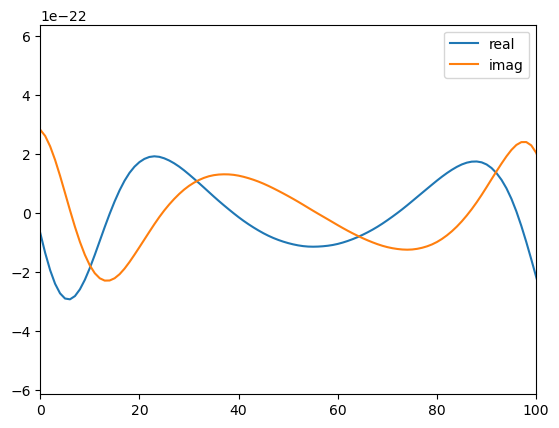

In [7]:
plt.plot(data.get().real, label='real')
plt.plot(data.get().imag, label='imag')
plt.xlim(0,100)
plt.legend(loc='upper right')
plt.show()

In [8]:
data_f = gwf.freq_wave(data)
gwf.SNR(data_f)

array(26.85986158)

# Likelihood, prior

In [9]:
def loglike(params):
    params = np.asarray(params)

    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a, p0, e0, dist, cosqS, phiS, Phi_phi0, Phi_r0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2
        qS = np.arccos(cosqS)
        phiK = phiS + np.pi/3

        htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                            Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
        
        res = data - htemp
        res_f = gwf.freq_wave(res)
        inner_res = gwf.inner(res_f, res_f)
        log_likes[i] = -0.5 * inner_res

    return log_likes


In [10]:
loglike(np.array([[np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, Phi_phi0, Phi_r0]]))

array([-1.39515088e-19])

In [11]:
def prior_transform(u):
    logm1lim = [5.9999848850e+00, 6.0000151150e+00]
    logm2lim = [1.4771121846e+00, 1.4771303249e+00]
    alim = [6.9997314536e-01, 7.0002685464e-01]
    p0lim = [7.4998522681e+00, 7.5001477319e+00]
    e0lim =  [3.9999300379e-01, 4.0000699621e-01]
    distlim =  [1.9909107694e+00, 2.0090892306e+00]
    cosqSlim =[8.7331905443e-01, 8.8184606935e-01]
    phiSlim = [9.9250152740e-01, 1.0074984726e+00]
    Phiphilim = [3.9410865400e-01, 4.0589134600e-01]
    Phirlim = [4.9717074288e-01, 5.0282925712e-01]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    # dist 
    transformed[:, 5] = (distlim[1] - distlim[0]) * u[:, 5] + distlim[0]

    # Uniform in cosqS 

    # qS
    transformed[:, 6] = (cosqSlim[1] - cosqSlim[0]) * u[:, 6] + cosqSlim[0]

    # phiS
    transformed[:, 7] = (phiSlim[1] - phiSlim[0]) * u[:, 7] + phiSlim[0]

    # Phi_phi0
    transformed[:, 8] = (Phiphilim[1] - Phiphilim[0]) * u[:, 8] + Phiphilim[0]

    # Phi_r0
    transformed[:, 9] = (Phirlim[1] - Phirlim[0]) * u[:, 9] + Phirlim[0]

    
    return transformed

# Visualization

In [12]:
# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

In [13]:
sampler = parismc.Sampler.load_state('./paris_1s_results/sampler_state.pkl')

In [14]:
import pickle
with open('cov_matrix_new.pkl', 'rb') as f:
    cov_matrix = pickle.load(f)

In [19]:
def visualize_marginal_distributions(sampler, savepath, true_values=None):
    """
    Create marginal distribution plots for each dimension 
    """
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
    except ImportError:
        print("Matplotlib/seaborn not available. Skipping visualization.")
        return

    print("\nCreating marginal distribution plots...")

    # Get samples and weights
    samples, weights = sampler.get_samples_with_weights(flatten=True)
    ndim = samples.shape[1]

    param_ranges = [
        [5.9999848850e+00, 6.0000151150e+00],
        [1.4771121846e+00, 1.4771303249e+00],
        [6.9997314536e-01, 7.0002685464e-01],
        [7.4998522681e+00, 7.5001477319e+00],
        [3.9999300379e-01, 4.0000699621e-01],
        [1.9909107694e+00, 2.0090892306e+00],
        [8.7331905443e-01, 8.8184606935e-01],
        [9.9250152740e-01, 1.0074984726e+00],
        [3.9410865400e-01, 4.0589134600e-01],
        [4.9717074288e-01, 5.0282925712e-01]
    ]

    param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'dist', 'cosqS', 'phiS','Phi_phi0', 'Phi_r0']


    # Visualization parameters
    bin_num = 50
    decay = 3  # For exponential smoothing

    def exponential_smoothing(hist, decay=1.0):
        """Apply exponential smoothing to histogram."""
        smoothed = np.zeros_like(hist)
        for i in range(len(hist)):
            weights_exp = np.exp(-decay * np.abs(np.arange(len(hist)) - i))
            weights_exp /= np.sum(weights_exp)  # normalize
            smoothed[i] = np.sum(hist * weights_exp)
        return smoothed

    # Set up the plot
    sns.set(style="white", context="talk")

    # Create subplot grid
    n_rows = (ndim + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(24, 3*n_rows))

    # Flatten axes for easier indexing
    if ndim == 1:
        axes = [axes]
    elif ndim <= 2:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    for i in range(ndim):
        ax = axes[i]

        # PARIS samples
        param_samples = samples[:, i]
        hist, bin_edges = np.histogram(param_samples, bins=bin_num, weights=weights, density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        hist = exponential_smoothing(hist, decay=decay)
        ax.plot(bin_centers, hist, color='green', linewidth=2, label='PARIS')

        # Add true value red line if provided
        if true_values is not None and i < len(true_values):
            ax.axvline(true_values[i], color='red', linestyle='--', linewidth=2,
                    label='True Value' if i == 0 else "")
            mean_val = true_values[i]
            std_val = np.sqrt(cov_matrix[i, i])

            x_gauss = np.linspace(param_ranges[i][0], param_ranges[i][1], 200)
            gauss_cov = norm.pdf(x_gauss, mean_val, std_val)
            ax.plot(x_gauss, gauss_cov, color='blue', linestyle='--', linewidth=2,
                    alpha=0.8, label='Gaussian (Cov)' if i == 0 else "")
            
        # Set x-axis limits to the prior ranges
        if i < len(param_ranges):
            ax.set_xlim(param_ranges[i][0], param_ranges[i][1])

        # Formatting
        param_name = param_names[i] if i < len(param_names) else f'Param {i+1}'
        ax.set_title(f'{param_name}', fontsize=14)
        ax.set_ylabel('Density', fontsize=12)
        # ax.set_xlim(0, 1)
        # ax.set_xticks([0, 0.5, 1])
        # ax.tick_params(axis='x', labelsize=10)
        ax.grid(True, alpha=0.3)

        # Add legend to first subplot
        if i == 0:
            ax.legend(fontsize=10, frameon=True)

    # Remove empty subplots if ndim is odd
    if ndim % 2 == 1 and ndim > 1:
        fig.delaxes(axes[-1])

    # Adjust layout
    plt.tight_layout()

    # Save the plot
    plot_filename = os.path.join(savepath, 'marginal_distributions.png')
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"Marginal distribution plot saved to: {plot_filename}")

    # Show plot if in interactive environment
    try:
        plt.show()
    except:
        pass

    # # Create a 2D corner plot for the first few dimensions
    # if ndim >= 2:
    #     create_corner_plot(samples, weights, savepath, max_dims=ndim)

In [20]:
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, Phi_phi0, Phi_r0])


Creating marginal distribution plots...
Marginal distribution plot saved to: ./paris_1s_results/marginal_distributions.png


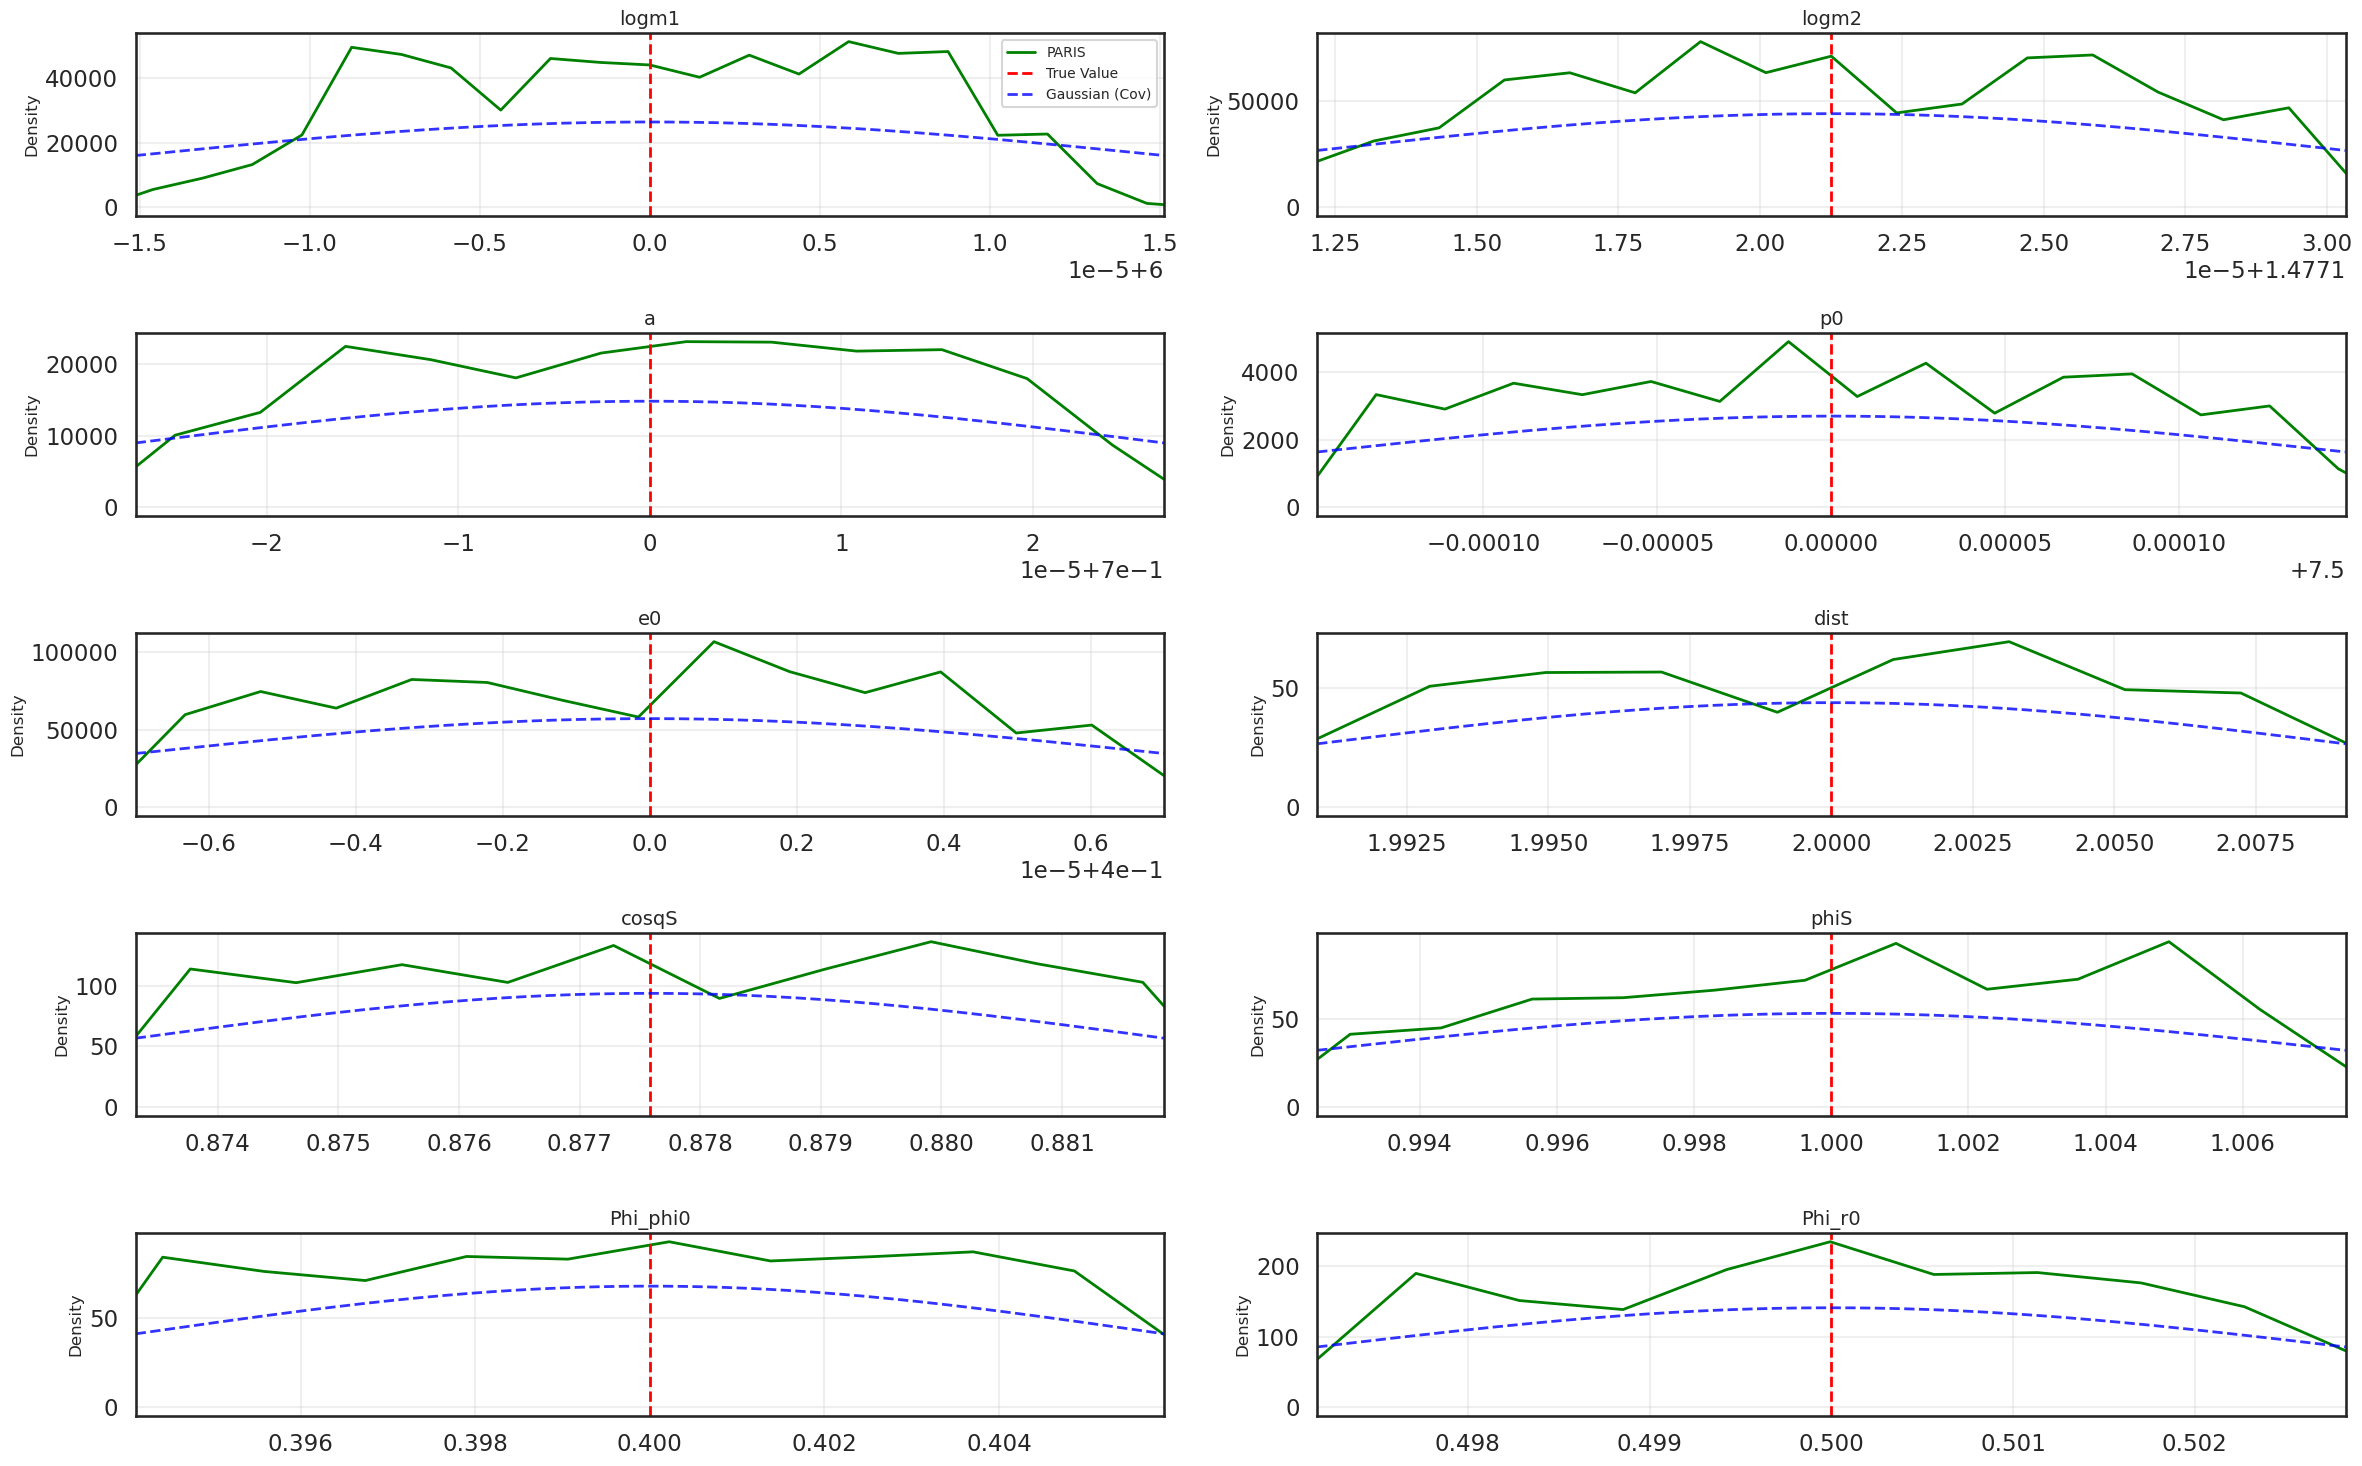

In [21]:
from scipy.stats import norm
visualize_marginal_distributions(sampler, './paris_1s_results/', true_values=param_true)


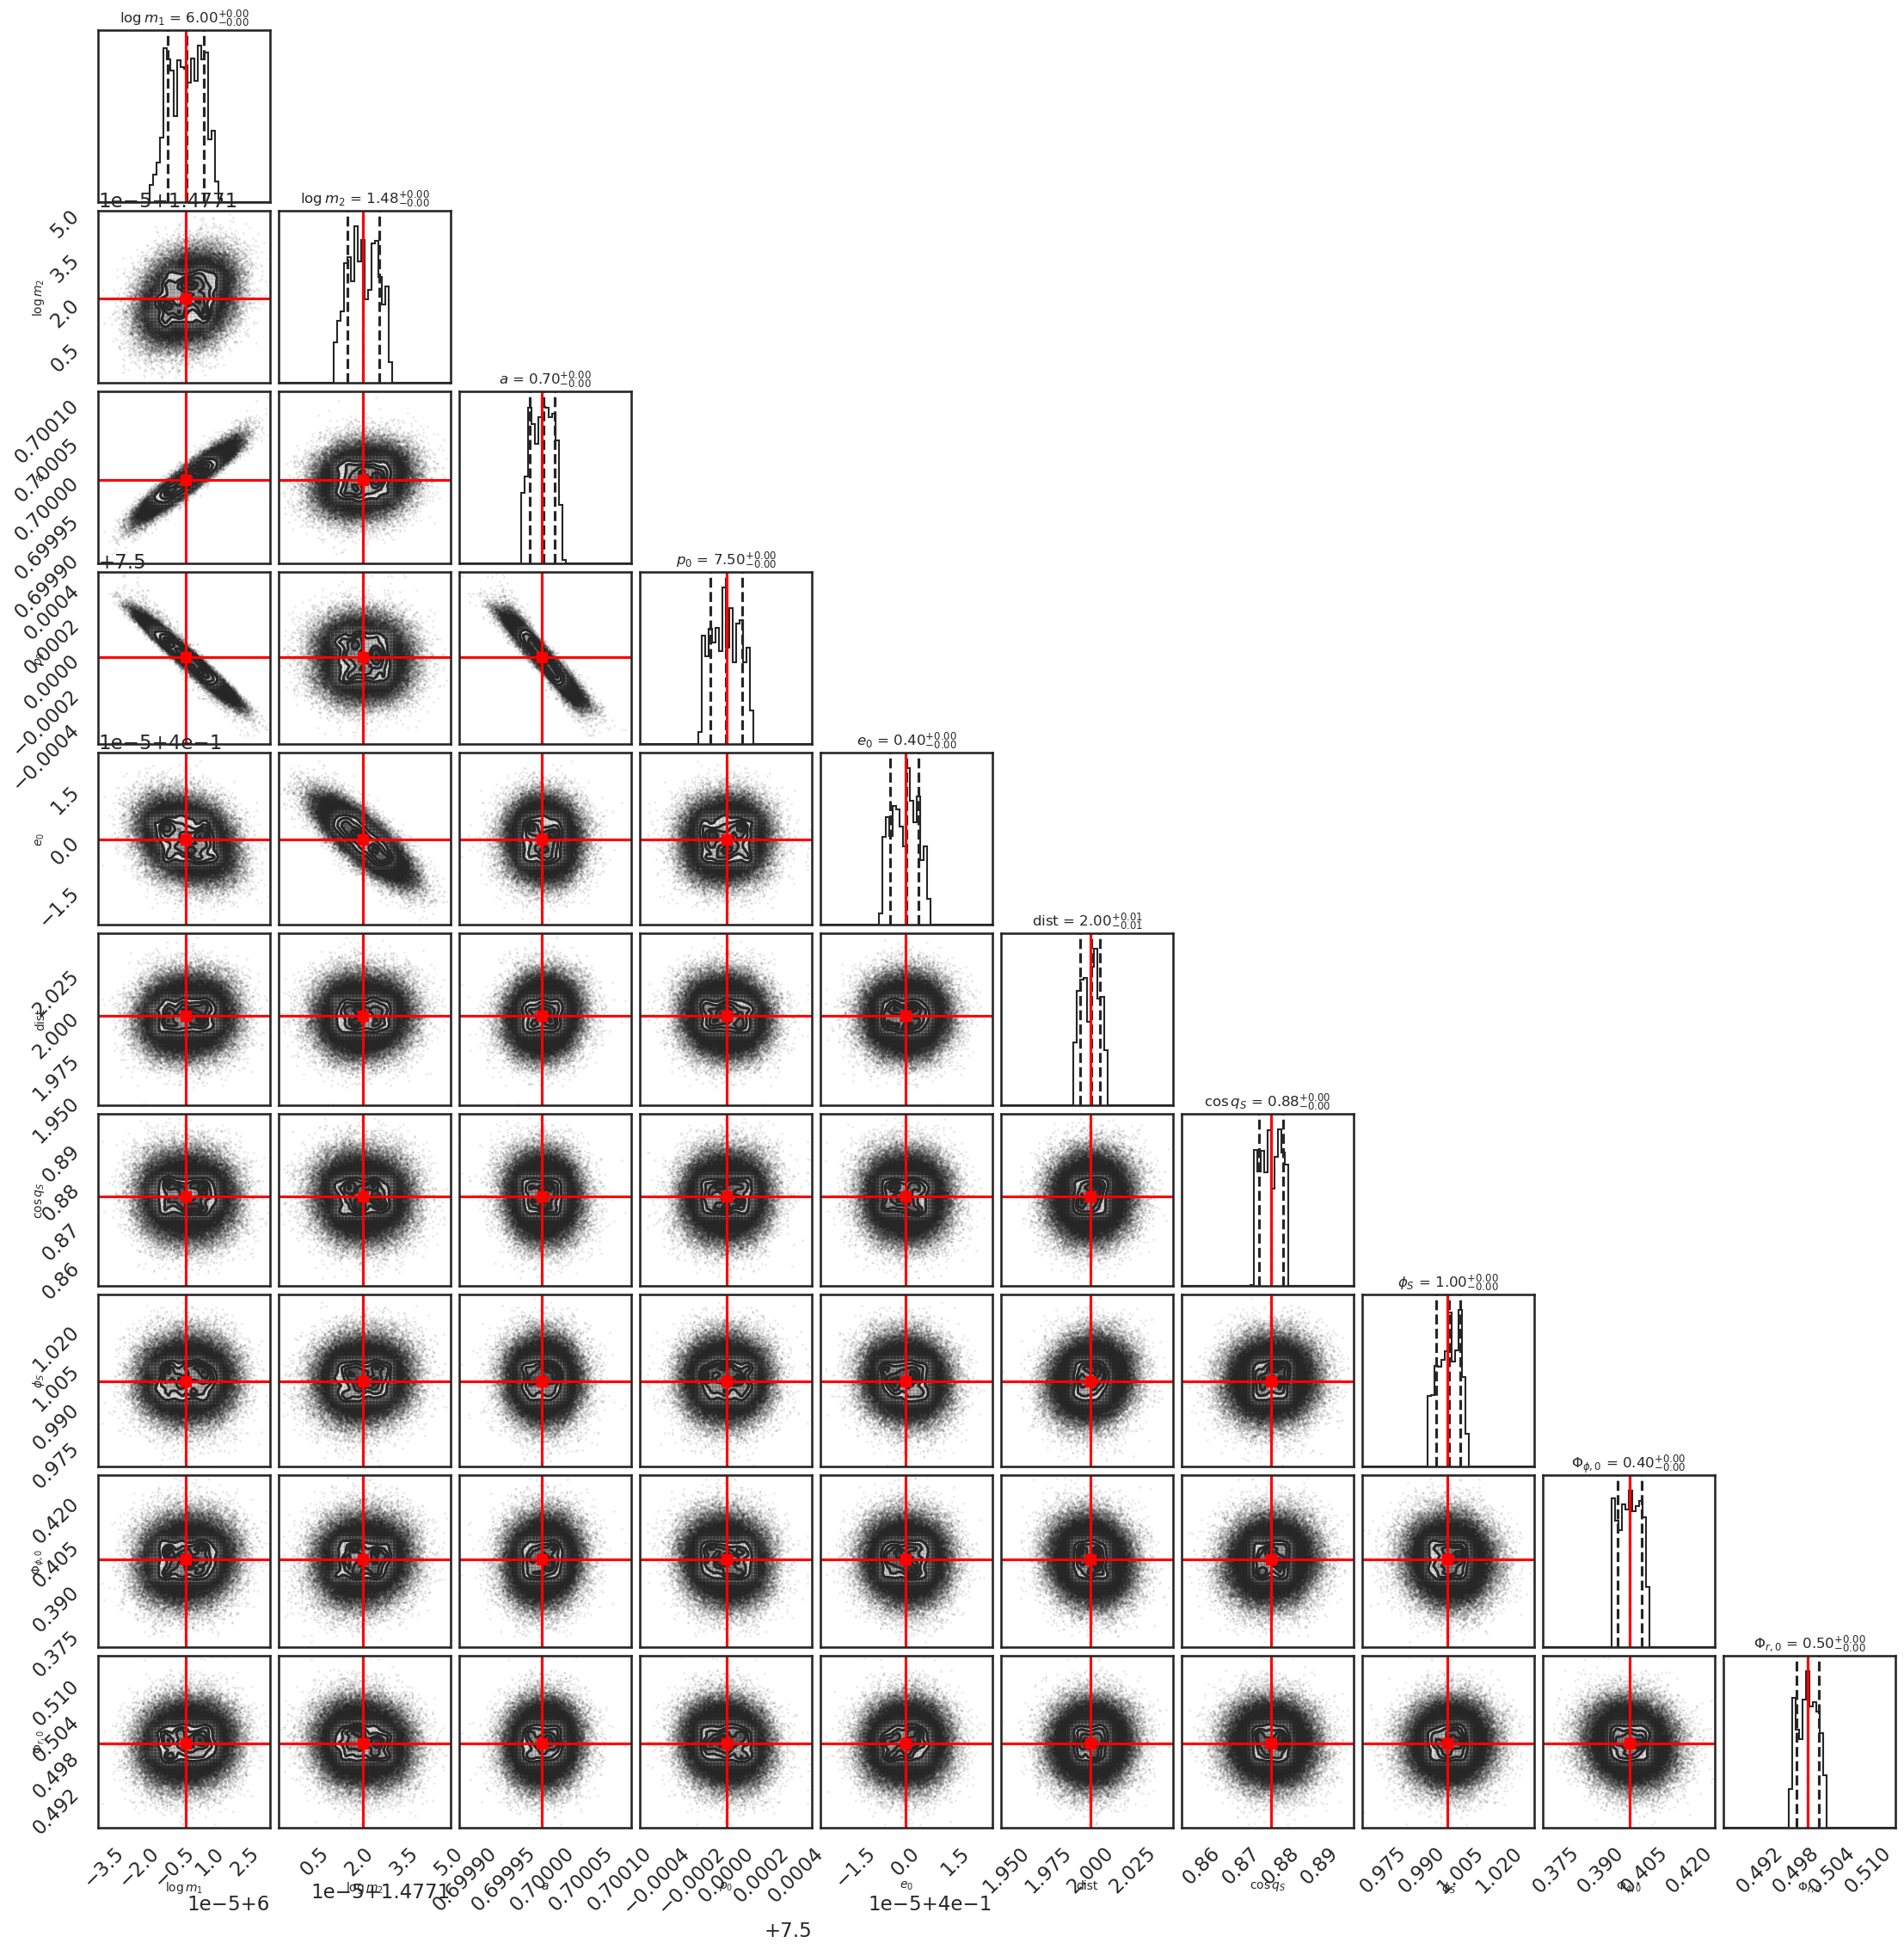

In [22]:
# try corner
import corner
samples, weights = sampler.get_samples_with_weights(flatten=True)
labels = [r'$\log{m_1}$', r'$\log{m_2}$',r'$a$',r'$p_0$',r'$e_0$',r'dist',r'$\cos{q_S}$', r'$\phi_S$',
        r'$\Phi_{\phi,0}$', r'$\Phi_{r,0}$']

fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma and median
    smooth=True,
    bins=50
)